# Machine Learning Fundamentals

# Week 5 – Task 1

# Handling Imbalanced & Messy Real-World Data

**Prepared By:** Abdul Raheem

**Course:** Machine Learning Fundamentals

**Organization:** Neurofive Solutions

**Dataset:** Credit Card Fraud Detection

---

## Problem Type

Binary Classification

This project demonstrates how to identify and handle imbalanced datasets using machine learning techniques. The Credit Card Fraud Detection dataset is used to analyze class imbalance, apply balancing techniques, retrain a classification model, and compare performance before and after balancing.

# Import Required Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE

# Load Dataset

In [24]:
df = pd.read_csv(r"D:\Machine Learning Fundamentals Course\Credit Card Fraud Dataset\creditcard.csv")

In [25]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [27]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [28]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


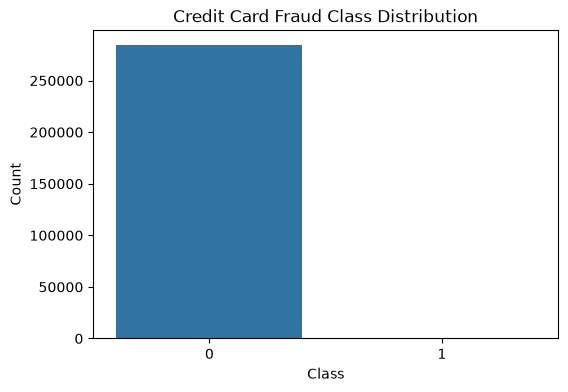

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Class")
plt.title("Credit Card Fraud Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

The dataset is extremely imbalanced.

Most transactions are legitimate (Class = 0), while only a very small percentage are fraudulent (Class = 1).

Training a model directly on this data may result in a classifier that predicts almost every transaction as legitimate while still achieving a very high accuracy.

In [30]:
X = df.drop("Class", axis=1)

y = df["Class"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [45]:
balanced_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

balanced_model.fit(X_train_smote, y_train_smote)

pred_after = balanced_model.predict(X_test)

print(classification_report(y_test, pred_after))

C:\Users\abdul Raheem\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.14      0.91      0.24        98

    accuracy                           0.99     56962
   macro avg       0.57      0.95      0.62     56962
weighted avg       1.00      0.99      0.99     56962



In [46]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [47]:
print("Before SMOTE")

print(y_train.value_counts())

print()

print("After SMOTE")

print(y_train_smote.value_counts())

Before SMOTE
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE
Class
0    227451
1    227451
Name: count, dtype: int64


In [48]:
print("Before SMOTE")

print(y_train.value_counts())

print()

print("After SMOTE")

print(y_train_smote.value_counts())

Before SMOTE
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE
Class
0    227451
1    227451
Name: count, dtype: int64


In [52]:
comparison = pd.DataFrame({

    "Model":[
        "Before SMOTE",
        "After SMOTE"
    ],

    "Accuracy":[
        accuracy_score(y_test,pred_before),
        accuracy_score(y_test,pred_after)
    ]

})

comparison

,Model,Accuracy
0,Before SMOTE,0.999192
1,After SMOTE,0.989888


# Conclusion

The Credit Card Fraud Detection dataset is highly imbalanced because fraudulent transactions represent less than 1% of all observations.

If a model predicts every transaction as legitimate, it would still achieve an accuracy greater than 99%, despite failing to detect any fraud.

Therefore, metrics such as Precision, Recall, and F1-score are much more informative because they measure how effectively the model identifies the minority (fraudulent) class.